# Neural Networks and CNNs with PyTorch

## Portfolio Summary

**Problem.** Построить нейросетевые модели на PyTorch и применить их к табличным, текстовым и/или image-задачам.

**Data.** Учебные датасеты для экспериментов с тензорами, полносвязными сетями и CNN.

**Approach.** PyTorch tensors, Dataset/DataLoader, обучение моделей, оптимизаторы, scheduler, CNN-архитектура и оценка качества.

**Result.** Проект показывает практическую работу с PyTorch beyond sklearn: датасеты, training loop, модельные классы и сверточные сети.

**Stack.** Python, PyTorch, torchvision, pandas, NumPy, scikit-learn, NLTK, PIL, matplotlib.


# Neural Network Components from Scratch (PyTorch)


В данной лабораторной работе мы научимся работать с PyTorch.

По нейронным сетям в интернете можно найти огромное количество информации и примеров (официальная документация фреймворка, Kaggle, даже ChatGPT, хотя последний стоит использовать с осторожностью) - вы можете использовать любые материалы в текущей работе, но будьте готовы ответить на вопросы по коду во время защиты.

Вспомогательные материалы:

[Курс по нейронным сетям](https://stepik.org/course/110281/syllabus)

[ШАД-овский курс по глубокому обучению](https://github.com/yandexdataschool/Practical_DL/tree/fall23)

[Неплохой курс чисто про PyTorch](https://www.learnpytorch.io/)

[Документация PyTorch](https://pytorch.org/)

В целом, содержательно данная работа дублирует часть курса по Глубокому обучению.


In [ ]:
%%capture
!pip install opendatasets

In [ ]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from collections import defaultdict
import opendatasets as od
plt.style.use('ggplot')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision
from torchvision.transforms import transforms

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import nltk
from nltk import word_tokenize, sent_tokenize
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## PyTorch Basics


С точки зрения синтаксиса PyTorch похож на NumPy, основная разница заключается в том, что данный фреймворк предназначен для автоматического расчета градиентов. [Вот тут](https://github.com/torch/torch7/wiki/Torch-for-Numpy-users) можно почитать про то, как соотносятся две эти библиотеки.


### 1


1. Создайте два вещественных тензора: $a$ размером (10, 2) и $b$ размером (, 20)

2. Создайте тензор c, являющийся тензором $b$, но размера (2, 2, 5)

3. Выведите первый столбец матрицы $a$ с помощью индексации

4. Создайте тензор $d$, являющийся тензором $b$, но размера (10, 2). Произведите все арифметические операции с тензорами $a$ и $d$


In [ ]:
# 1
a = torch.randn(10, 2)  # случайные значения из норм распред
b = torch.randn(20)

print(f'Тензор a:\n{a}\n\nТензор b:\n{b}')

Тензор a:
tensor([[-0.7313,  0.1967],
        [-0.9080, -0.5969],
        [-0.3143,  0.8282],
        [-0.6727,  1.1346],
        [-0.0545, -0.2017],
        [ 0.7848, -0.4159],
        [-0.5947, -0.5847],
        [-0.4394,  1.6173],
        [ 0.0935,  0.0805],
        [ 1.6989,  0.4428]])

Тензор b:
tensor([-0.8064, -0.1427, -0.1878, -0.7385, -0.1301,  1.6577,  0.3214, -0.7765,
        -1.0683, -2.1105, -0.7923, -1.0857,  0.6904, -0.0139, -0.8477,  1.4873,
         0.7725, -0.1153, -0.2954, -1.2711])


In [ ]:
# 2
c = b.view(2, 2, 5)
print(f'Тензор:\n{c}')

Тензор:
tensor([[[-0.8064, -0.1427, -0.1878, -0.7385, -0.1301],
         [ 1.6577,  0.3214, -0.7765, -1.0683, -2.1105]],

        [[-0.7923, -1.0857,  0.6904, -0.0139, -0.8477],
         [ 1.4873,  0.7725, -0.1153, -0.2954, -1.2711]]])


In [ ]:
# 3
print(f'Первый столбец матрицы a:')
a[:,0]

Первый столбец матрицы a:


tensor([-0.7313, -0.9080, -0.3143, -0.6727, -0.0545,  0.7848, -0.5947, -0.4394,
         0.0935,  1.6989])

In [ ]:
# 4
torch.set_printoptions(precision=4, sci_mode=False)  # установка 4 знаков после запятой и отключение мат. вывода (1e-5)

d = b.view(10, 2)

print('Поэлементное сложение:')
print(a + d)

print('\nПоэлементное вычитание:')
print(a - d)

print('\nПоэлементное умножение:')
print(a * d)

print('\nПоэлементное деление:')
print(a / d)

print('\nМатричное умножение:')
print(a.T @ d)

Поэлементное сложение:
tensor([[-1.5377,  0.0539],
        [-1.0958, -1.3354],
        [-0.4444,  2.4860],
        [-0.3514,  0.3581],
        [-1.1228, -2.3122],
        [-0.0075, -1.5016],
        [ 0.0957, -0.5986],
        [-1.2871,  3.1046],
        [ 0.8660, -0.0348],
        [ 1.4036, -0.8283]])

Поэлементное вычитание:
tensor([[ 0.0751,  0.3394],
        [-0.7201,  0.1417],
        [-0.1841, -0.8295],
        [-0.9941,  1.9111],
        [ 1.0138,  1.9089],
        [ 1.5771,  0.6698],
        [-1.2851, -0.5709],
        [ 0.4083,  0.1300],
        [-0.6790,  0.1958],
        [ 1.9943,  1.7140]])

Поэлементное умножение:
tensor([[ 0.5897, -0.0281],
        [ 0.1705,  0.4408],
        [ 0.0409,  1.3730],
        [-0.2162, -0.8811],
        [ 0.0582,  0.4257],
        [-0.6218,  0.4515],
        [-0.4106,  0.0081],
        [ 0.3725,  2.4054],
        [ 0.0722, -0.0093],
        [-0.5018, -0.5629]])

Поэлементное деление:
tensor([[ 0.9069, -1.3779],
        [ 4.8342,  0.8082],
     

### 2


1. Создайте тензор *целых чисел* `images` размерности (100, 200, 200, 3) (можно интерпретировать это как 100 картинок размера 200х200 с тремя цветовыми каналами, то есть 100 цветных изображений 200х200). Заполните его нулями  

2. Сделайте так, чтобы у $i$-ой по порядку картинки была нарисована белая полоса толщиной два пикселя в строках, которые соответствуют номеру картинки * 2. Например, у 3-ей по порядку картинки белая полоска будет занимать 6 и 7 строки, у 99 - 198 и 199. Сделать белую строку можно, записав в ячейки тензора число 255 (по всем трём каналам). Выведите несколько примеров с помощью `pyplot`  

3. Посчитайте среднее тензора `images` по 1-ой оси (по сути - средняя картинка), умножьте полученный тензор на 70. Нарисуйте с помощью `pyplot`, должна получиться серая картинка (при взятии среднего нужно привести тензор к float с помощью `.float()`, при отрисовке обратно к int с помощью `.int()`)


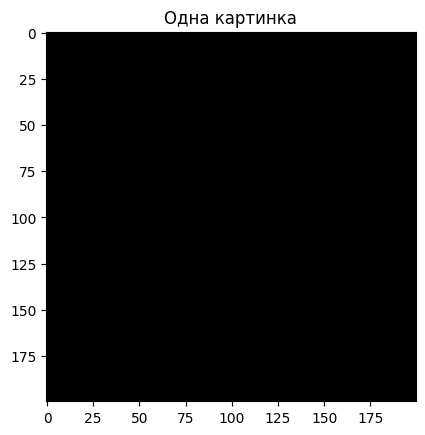

In [ ]:
# 1
images = torch.zeros(100, 200, 200, 3, dtype=torch.uint8)
plt.imshow(images[0])
plt.title('Одна картинка')
plt.show()

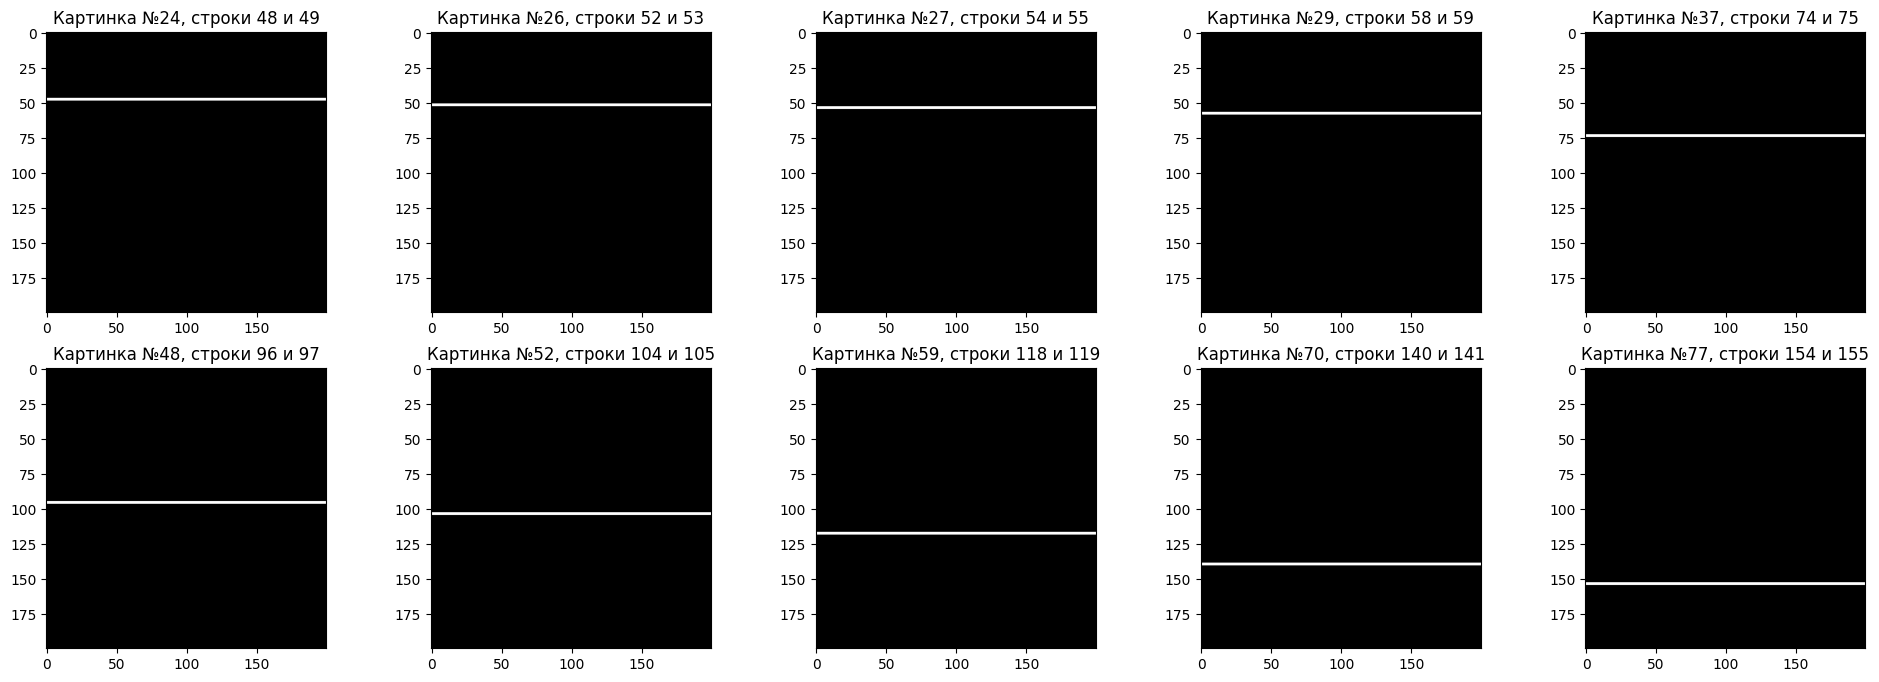

In [ ]:
# 2
plt.figure(figsize=(24, 8))

nums = np.random.randint(0, 100, 10)
i = 0

for num, image in enumerate(images):
    line_1, line_2 = num*2 + 1, num*2 + 2

    if num == 99:
        image[line_1] = 255
    else:
        image[line_1] = 255
        image[line_2] = 255

    if num in nums:
        i += 1
        plt.subplot(2, 5, i)
        plt.imshow(image)
        plt.title(f'Картинка №{num + 1}, строки {line_1 + 1} и {line_2 + 1}')

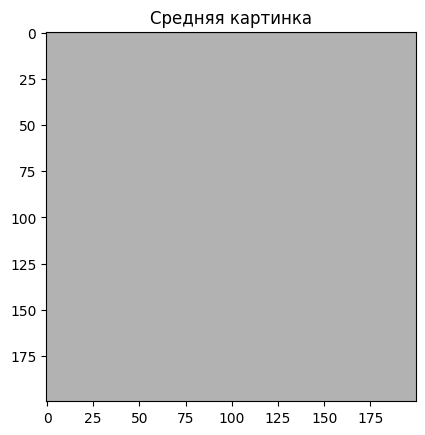

In [ ]:
# 3
mean_image = images.float().mean(dim=0) * 70
mean_image = mean_image.int()
plt.imshow(mean_image)
plt.title('Средняя картинка')
plt.show()

### 3


1. Смените среду выполнения на GPU (в Colab нажмите в меню сверху: `Runtime` -> `Change Runtime Type` -> `GPU`, где изначально стоит `None` (`Среда выполнение` - `Сменить среду выполнения`))

2. Объявите тензор $a$ размера (2, 3, 4) и тензор $b$ размера (1, 8, 3) на GPU, иницилизируйте их случайно равномерно (`.uniform_()`)

3. Измените форму тензора $b$, чтобы она совпадала с формой тензора $a$, получите тензор $c$.

4. Переместите тензоры $a$ и $c$ на CPU.

5. Объявите тензор `L = torch.mean((c - a) `**` 2)` и посчитайте градиент $L$ по $c$ ( то есть $\frac{\partial{L}}{\partial{c}})$. Выведите градиент $L$ по $c$. Также вычислите его вручную, чтобы проверить себя.


In [ ]:
# 2
a = torch.empty(2, 3, 4).uniform_()
b = torch.empty(1, 8, 3).uniform_()

print(f'Тензор a:\n{a}\n\nТензор b:\n{b}')

Тензор a:
tensor([[[0.5821, 0.3737, 0.4477, 0.1661],
         [0.7151, 0.4777, 0.0550, 0.5848],
         [0.2844, 0.9292, 0.0060, 0.7970]],

        [[0.3874, 0.5877, 0.8833, 0.2851],
         [0.7060, 0.7975, 0.3498, 0.2851],
         [0.8255, 0.5621, 0.7696, 0.8440]]])

Тензор b:
tensor([[[0.4343, 0.6312, 0.7186],
         [0.9862, 0.1273, 0.6536],
         [0.7156, 0.3976, 0.7813],
         [0.9820, 0.9589, 0.0739],
         [0.3903, 0.6270, 0.2753],
         [0.9736, 0.4383, 0.0858],
         [0.0701, 0.6945, 0.6406],
         [0.1361, 0.7302, 0.2305]]])


In [ ]:
# 3
c = b.view(2, 3, 4)

print(f'Тензор c:\n{c}')

Тензор c:
tensor([[[0.4343, 0.6312, 0.7186, 0.9862],
         [0.1273, 0.6536, 0.7156, 0.3976],
         [0.7813, 0.9820, 0.9589, 0.0739]],

        [[0.3903, 0.6270, 0.2753, 0.9736],
         [0.4383, 0.0858, 0.0701, 0.6945],
         [0.6406, 0.1361, 0.7302, 0.2305]]])


In [ ]:
# 4
a_cpu = a.cpu()
c_cpu = c.cpu()

In [ ]:
# 5
c.requires_grad_(True)
L = torch.mean((c_cpu - a_cpu)**2)
L.backward()

grad_c = c_cpu.grad
grad_c_my = 2*(c_cpu - a_cpu)/24

print(f'Градиент L по c (автоматический):\n {grad_c}\n')
print(f'Градиент вручную:\n {grad_c_my}\n')
print(f'Разница двух градиентов:\n {(grad_c - grad_c_my).sum():.10f}')

Градиент L по c (автоматический):
 tensor([[[-0.0123,  0.0215,  0.0226,  0.0683],
         [-0.0490,  0.0147,  0.0551, -0.0156],
         [ 0.0414,  0.0044,  0.0794, -0.0603]],

        [[ 0.0002,  0.0033, -0.0507,  0.0574],
         [-0.0223, -0.0593, -0.0233,  0.0341],
         [-0.0154, -0.0355, -0.0033, -0.0511]]])

Градиент вручную:
 tensor([[[-0.0123,  0.0215,  0.0226,  0.0683],
         [-0.0490,  0.0147,  0.0551, -0.0156],
         [ 0.0414,  0.0044,  0.0794, -0.0603]],

        [[ 0.0002,  0.0033, -0.0507,  0.0574],
         [-0.0223, -0.0593, -0.0233,  0.0341],
         [-0.0154, -0.0355, -0.0033, -0.0511]]], grad_fn=<DivBackward0>)

Разница двух градиентов:
 0.0000000091


## Neural Network Basics


Кратко обсудим основные концепции, понимание которых необходимо для работы с PyTorch. В других фреймворках для нейронных сетей всё очень похоже.

1. **Датасеты**
  
  В PyTorch датасеты представлены классами `torch.utils.data.Dataset` или его наследниками. Они позволяют загружать данные и предоставляют доступ к ним для обучения и валидации.

2. **Нейронные сети**

  *Слои*

  Нейронные сети в PyTorch строятся с использованием `torch.nn.Module` (не единственный, но самый распространенный способ). Слои определяются внутри этих модулей и могут быть полносвязными (`torch.nn.Linear`), сверточными (`torch.nn.Conv2d`), рекуррентными (`torch.nn.LSTM`, `torch.nn.GRU`) и другими. Сло имеют входную и выходную размерность. В нейронной сети выходная размерность слоя должна быть равна входной размерности последующего слоя.

  *Функции активации*

  Функции активации, такие как ReLU (`torch.nn.ReLU`), Sigmoid (`torch.nn.Sigmoid`), Tanh (`torch.nn.Tanh`) и другие, применяются к выходу слоя для добавления нелинейности в сеть.

  *Лосс-функции*

  Лосс-функции измеряют расхождение между прогнозами модели и фактическими значениями. В зависимости от типа задачи могут использоваться различные функции активации, например, `torch.nn.CrossEntropyLoss` для классификации и `torch.nn.MSELoss` для регрессии.

  *Оптимизаторы*

  Оптимизаторы в PyTorch, такие как `torch.optim.SGD`, `torch.optim.Adam`, `torch.optim.Adagrad` и другие, используются для обновления параметров сети в процессе обучения с целью минимизации функции потерь.

  *Планировщики (шедулеры)*

  Планировщики позволяют динамически изменять скорость обучения в процессе обучения. Например, `torch.optim.lr_scheduler.ReduceLROnPlateau` уменьшает скорость обучения, если ошибка перестает уменьшаться, а `torch.optim.lr_scheduler.StepLR` или `torch.optim.lr_scheduler.CosineAnnealingLR` изменяют скорость обучения в заданные моменты или с периодическим расписанием.

3. **Обучение и валидация**

  Обучение модели включает в себя передачу данных через сеть, вычисление функции потерь, вычисление градиентов, обновление весов с использованием оптимизатора и повторение этого процесса на протяжении нескольких эпох. После обучения модели необходимо провести валидацию на независимом наборе данных для оценки ее производительности.


[Визуализация работы нейронных сетей](https://playground.tensorflow.org/).

Потренируемся писать полный цикл обучения нейронной сети на [следующем наборе данных](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data).

P.S. предлагаемая архитектура сети не является оптимальной, но позволяет научиться работать с основными строительными блоками PyTorch-а.


Прочитайте датасет (можно использовать библиотеку `opendatasets` для выгрузки данных с Kaggle). Посчитайте основные числовые характеристики для каждого столбца. Проанализируйте датасет на предмет дисбаланса классов. Сделайте вывод о необходимости каких-либо преобразований над данными.

Разбейте выборку на тренировочную и тестовую (`test_size=0.2, random_state=42`), проведите необходимые преобразования.


In [ ]:
df = pd.read_csv('data.csv')
df.drop(['Unnamed: 32', 'id'], axis=1, inplace=True)

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

В датасете данные о пациентах, у которых найдена опухоль молочной железы. Определяется злокачественная (M) ли она или доброкачественная (B)


In [ ]:
# Проверка дисбаланса классов, B - доброкачественные, M - злокачественные
display(df['diagnosis'].value_counts())
display(df['diagnosis'].value_counts() / df.shape[0])

,count
diagnosis,
B,357
M,212


,count
diagnosis,
B,0.627417
M,0.372583


In [ ]:
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

X_train, X_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['diagnosis'])

Создайте класс датасета. Типы данных, которые вам потребуются: `dtype=torch.float32`, `dtype=torch.long`.

Инициализируйте даталоадеры (`batch_size=32`) для тренировочных и тестовых данных. Для теста данные перемешивать (параметр `shuffle`) не надо!


In [ ]:
class CustomDataset(Dataset):
    def __init__(self, dataframe):
        X = dataframe.drop(['diagnosis'], axis=1).values
        y = dataframe['diagnosis'].values

        self.scaler = StandardScaler()
        X_scaler = self.scaler.fit_transform(X)

        self.data = torch.tensor(X_scaler, dtype=torch.float32)
        self.target = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.target[idx]


train_dataset = CustomDataset(X_train)
test_dataset = CustomDataset(X_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Создайте полносвязную нейронную сеть из нескольких слоёв. Между слоями используйте ReLU.


In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetwork, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        result = self.layers(x)
        return result

Следующий небольшой кусочек кода написан за вас. В нём используется кросс-энтропия в качестве функции потерь. Вспомните, какими характеристиками обладает данная функция и в чём особенность её реализации в PyTorch.

Письменно ответьте на вопрос, как сигмоидальная функция потерь соотносится с кросс-энтропийной.


In [ ]:
model = NeuralNetwork(input_size=X_train.shape[1] - 1).to(device)  # -1 за счет таргета
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

num_epochs = 15
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

In [ ]:
# Функция потерь с учетом дисбаланса классов
class_counts = torch.bincount(torch.tensor(df['diagnosis'].values))
weights = (1. / (class_counts.float())).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

`ОТВЕТ:`

Кросс-энтропийя оценивает разницу между предсказанными вероятностями классов и истинными метками классов. А сигмоидная функция возвращает вероятности принадлежания объекта к каждому из классов. Для бинарной классификации их обычно используют вместе.


Напишите функции для тренировки и тестирования модели. Не забудьте про `optimizer.zero_grad()` при тренировке и `with torch.no_grad()` в тесте.

Также обратите внимание, что шаг планировщика нужно совершать после шага оптимизатора.


In [ ]:
def train(model, train_loader, criterion, optimizer, scheduler, device):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in tqdm(train_loader):
      # Перемещение данных на устройство (GPU или CPU)
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Обнуление градиентов параметров модели
        optimizer.zero_grad()

        # Прямой проход: получение прогнозов от модели
        outputs = model(inputs)

        # Вычисление значения функции потерь
        loss = criterion(outputs, labels)

        # Обратное распространение: вычисление градиентов
        loss.backward()

        # Обновление параметров модели с помощью оптимизатора
        optimizer.step()

        # Вычисление точности модели (Accuracy)
        pred = torch.max(outputs.data, 1)[1]
        total_train += labels.size(0)
        correct_train += (pred == labels).sum().item()

        # Аккумулирование потерь по батчам
        running_loss += loss.item() * inputs.size(0)

    # Обновление шага расписания (scheduler)
    scheduler.step()

    # Вычисление средней потери и точности на тренировочном наборе данных
    train_loss = running_loss / total_train
    train_accuracy = correct_train / total_train

    return train_loss, train_accuracy


def test(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        # Проход по данным тестового загрузчика
        for inputs, labels in tqdm(test_loader):
            # Перемещение данных на устройство (GPU или CPU)
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Получение прогнозов от модели
            outputs = model(inputs)

            # Вычисление значения функции потерь
            loss = criterion(outputs, labels)

            # Вычисление точности модели (Accuracy)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

            # Аккумулирование потерь по батчам
            running_loss += loss.item() * inputs.size(0)

    # Вычисление средней потери и точности на тестовом наборе данных
    test_loss = running_loss / total_test
    test_accuracy = correct_test / total_test

    return test_loss, test_accuracy

Создайте цикл обучения вашей нейронной сети, используя написанные ранее функции.

Печатайте прогресс на каждой эпохе (`train_loss, train_accuracy, test_loss, test_accuracy`).

Постройте графики лосса и точности. Должно получиться что-то такое:

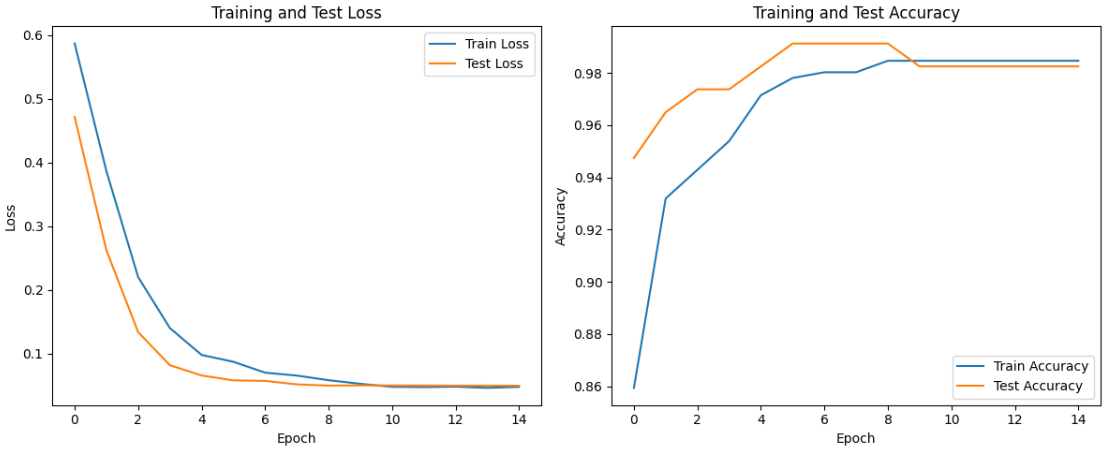


In [ ]:
for epoch in range(num_epochs):
    train_loss, train_accuracy = train(model, train_loader, criterion, optimizer, scheduler, device)
    test_loss, test_accuracy = test(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'  Train Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.2f}%')
    print(f'  Test Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.2f}%\n')

# Сохранение модели
torch.save(model.state_dict(), 'model_checkpoint.pth')

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/15
  Train Loss: 0.6705, Accuracy: 0.57%
  Test Loss: 0.6133, Accuracy: 0.95%



  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 14/15
  Train Loss: 0.0449, Accuracy: 0.99%
  Test Loss: 0.0815, Accuracy: 0.97%



  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 15/15
  Train Loss: 0.0444, Accuracy: 0.99%
  Test Loss: 0.0810, Accuracy: 0.97%



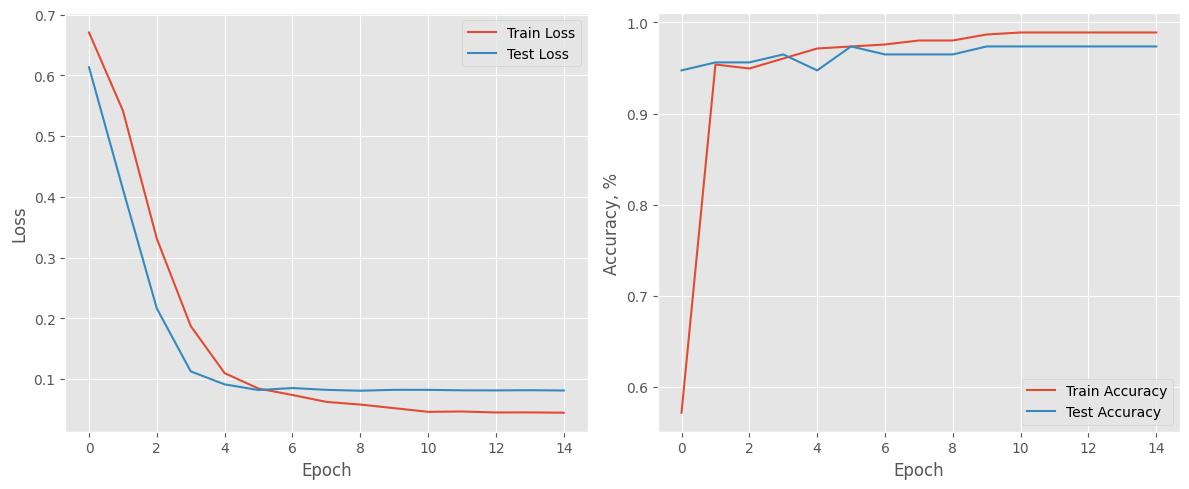

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy, %')
plt.legend()

plt.tight_layout()
plt.show()

## Специальные архитектуры нейронных сетей


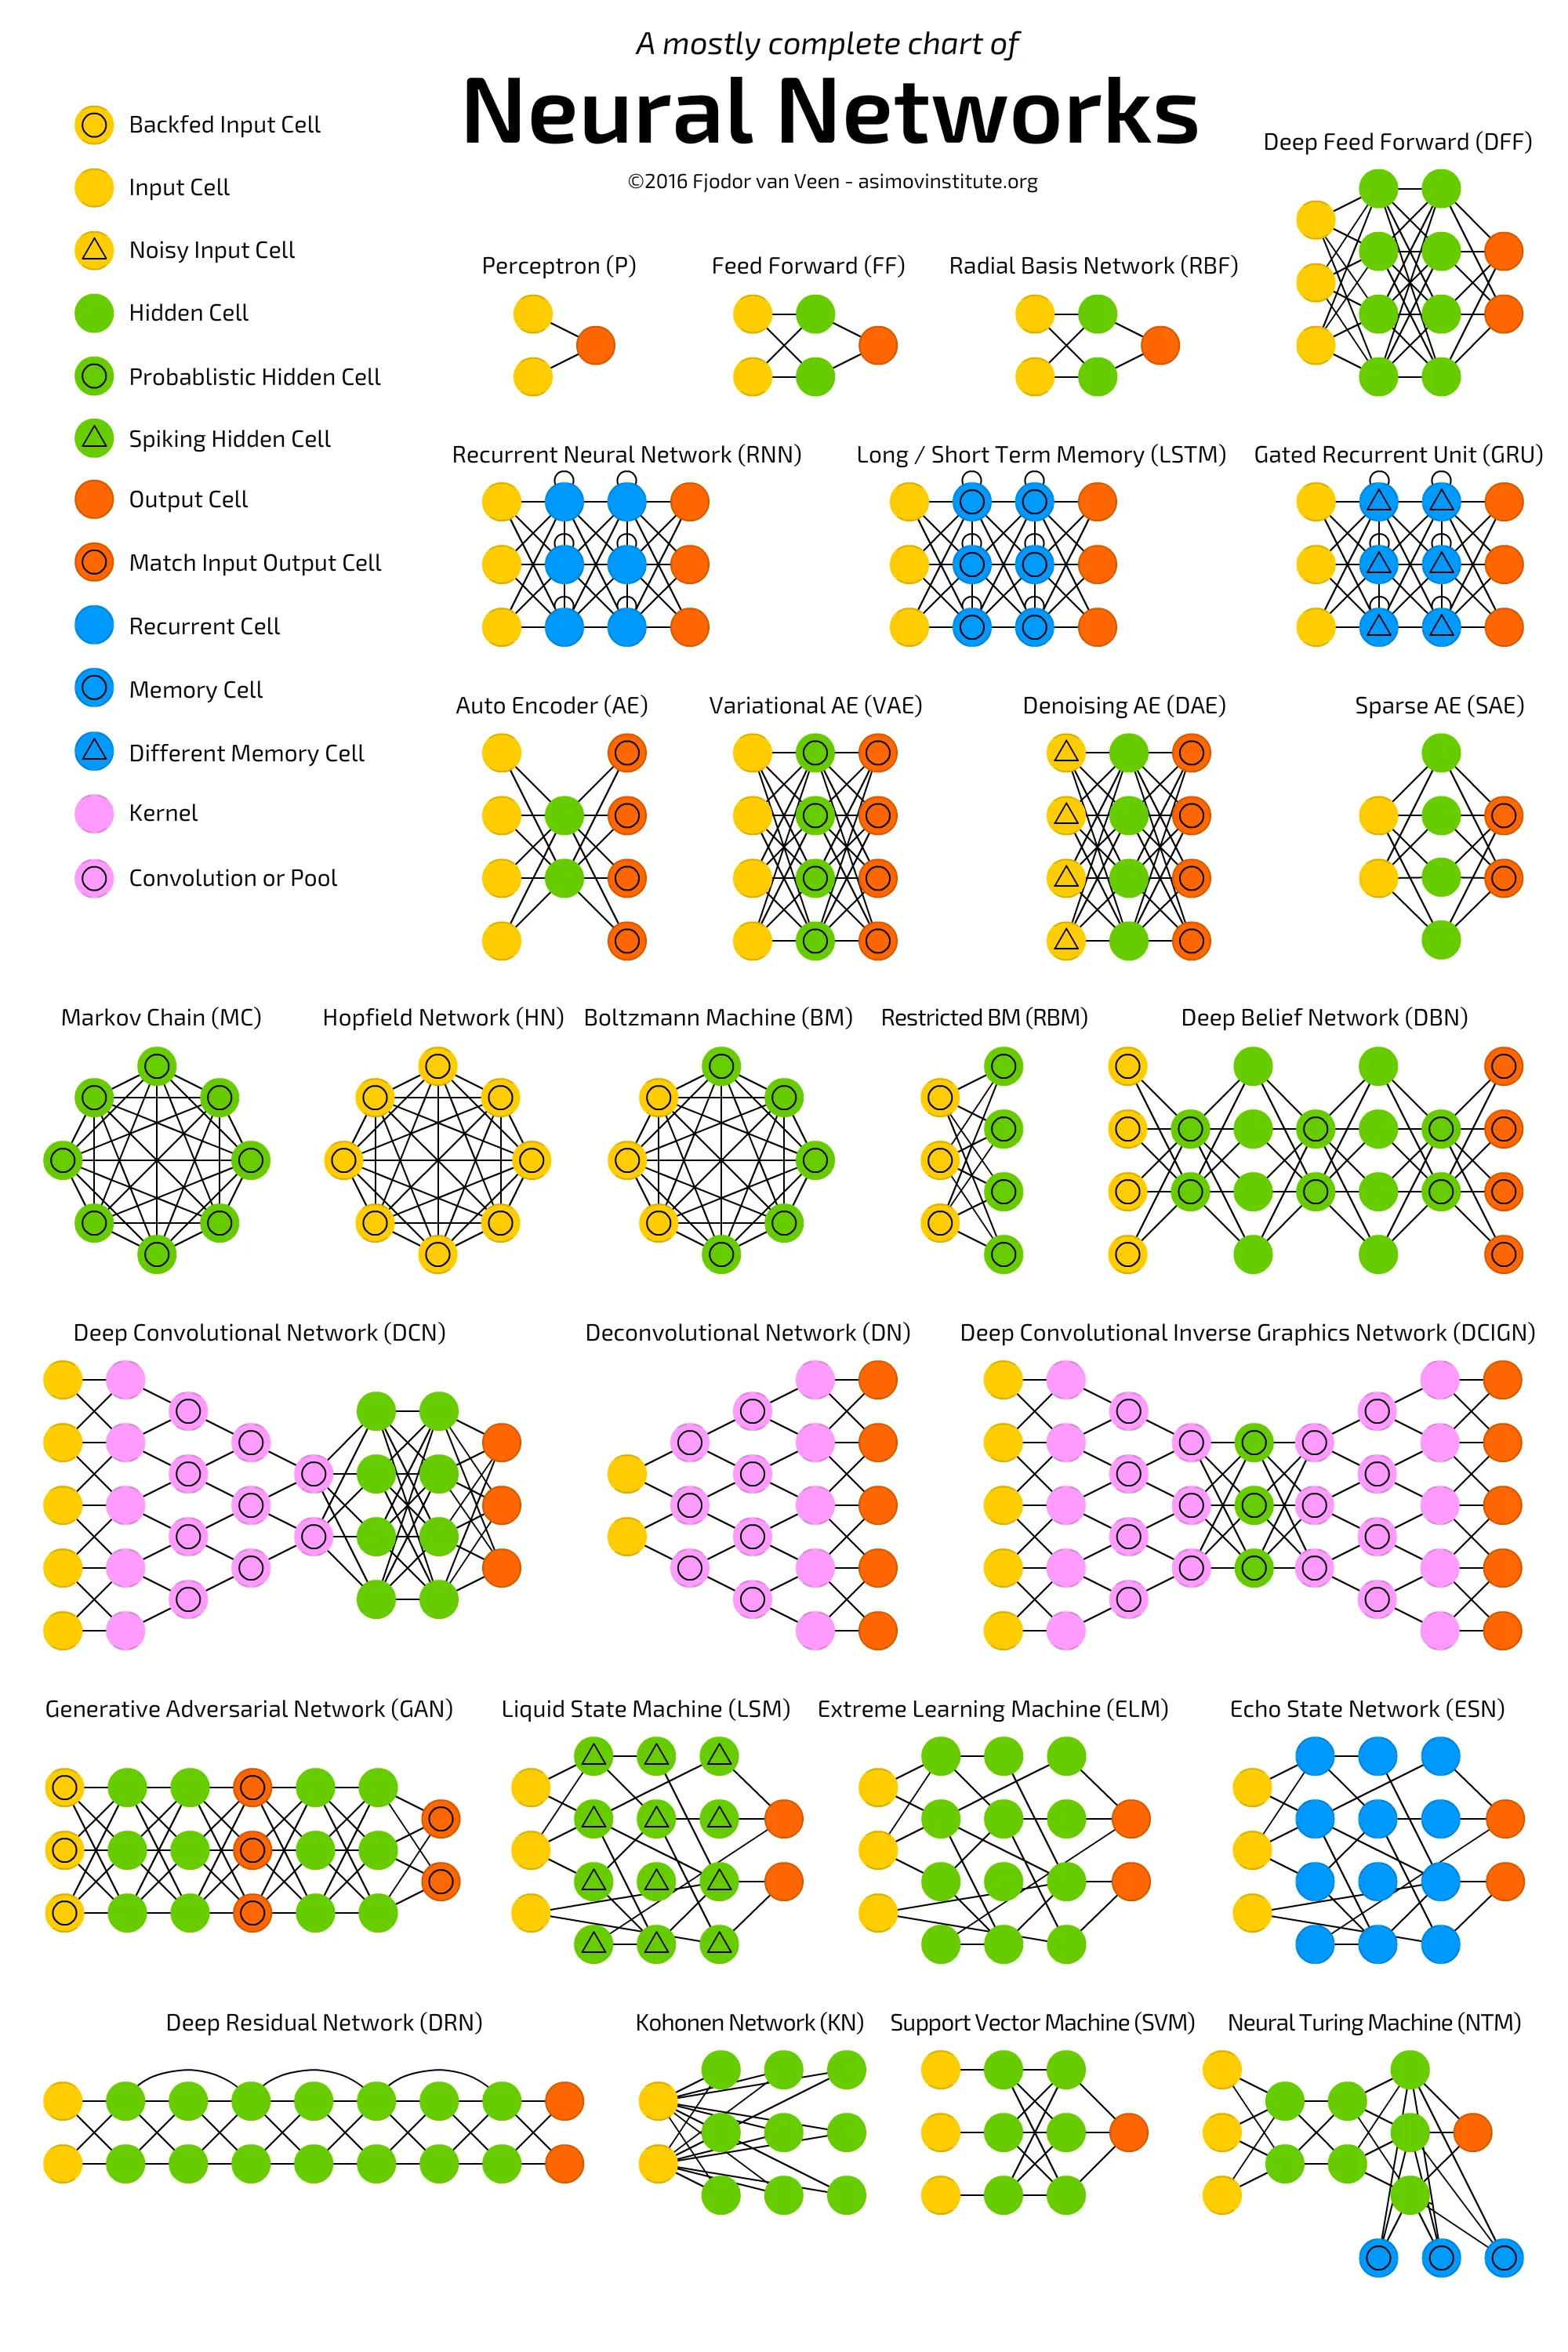

[Источник картинки](https://towardsdatascience.com/the-mostly-complete-chart-of-neural-networks-explained-3fb6f2367464)


В последующих заданиях можно использовать предоставленные датасеты ЛИБО найти какой-либо свой, обладающий схожими характеристиками.


### CNN


Свёрточные нейронные сети работают по принципу "возьмем фильтры с настраиваемыми весами и будем изменять эти веса так, чтобы фильтры выделяли те признаки, которые помогут нам решить задачу". Обычно свёрточные нейронные сети состоят из блоков свёртки и пулинга (уменьшение размерности), поверх которых добавляются несколько полносвязных линейных слоёв. [Визуализация работы свёрточной нейронной сети](https://poloclub.github.io/cnn-explainer/)


Будем решать задачу многоклассовой классификации. Датасет возьмем [отсюда](https://www.kaggle.com/datasets/puneet6060/intel-image-classification/data). Он содержит картинки с различными пейзажами. Присутсвуют такие классы, как 'buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'.

Скачайте датасет (можно использвоать библиотеку `opendatasets`)


In [ ]:
od.download('https://www.kaggle.com/datasets/puneet6060/intel-image-classification')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: marynadik
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification


Создайте даталоадеры для тренировочных и тестовых данных. Используйте `torchvision.datasets.ImageFolder`. Одним из параметров данной функции является `transform`. Попробуйте применить к вашим данным какие-либо [трансформации](https://pytorch.org/vision/stable/transforms.html).


In [ ]:
train_path = "intel-image-classification/seg_train/seg_train"
test_path = "intel-image-classification/seg_test/seg_test"
batch_size = 16

train_transformer = transforms.Compose([
    transforms.Resize(324),
    transforms.RandomCrop(256),
    transforms.RandomHorizontalFlip(p=0.5),                          # 50% шанс отражения
    transforms.ColorJitter(brightness=0.2, contrast=0.25),           # Случайные изменения яркости и контрастности
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transformer = transforms.Compose([
    transforms.Resize(324),
    transforms.RandomCrop(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.ImageFolder(root=train_path, transform=train_transformer)
test_dataset = torchvision.datasets.ImageFolder(root=test_path, transform=test_transformer)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Выведем пару картинок, обратившись к содержимому даталоадеров.


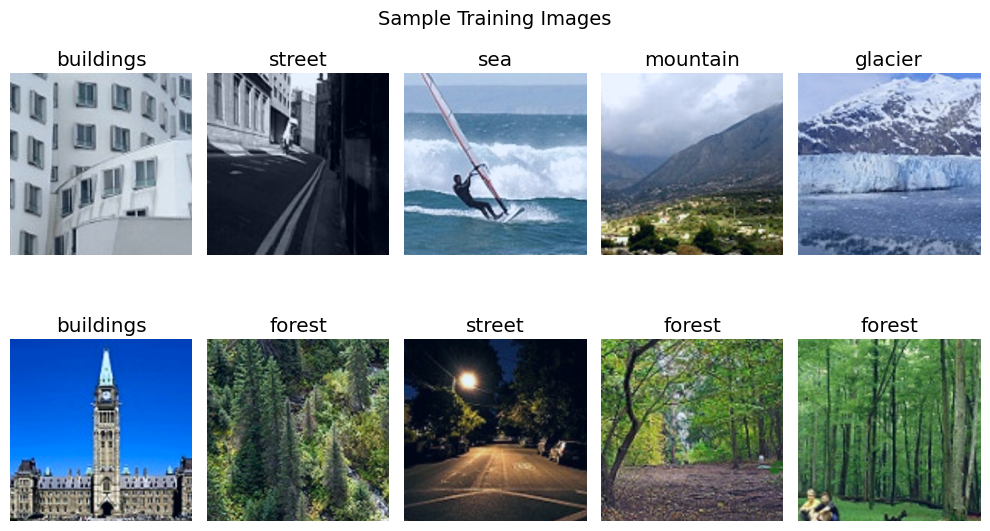

In [ ]:
images, labels = next(iter(train_loader))
class_names = train_loader.dataset.classes

fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(10, 6))
idx = 0

for i in range(2):
    for j in range(5):
        label = class_names[labels[idx].item()]
        ax[i, j].set_title(f"{label}")
        img = images[idx]

        img = (255*(img - img.min()) / (img.max() - img.min())).int()  # обратное преобразование из-за трансформаций. возможно, вам оно не пригодится

        npimg = np.transpose(img.numpy(), (1, 2, 0))
        ax[i, j].imshow(npimg)
        ax[i, j].axis("off")
        idx += 1

plt.tight_layout()
plt.suptitle("Sample Training Images", fontsize=14)
plt.show()

Реализуйте свёрточную нейронную сеть и обучите её, используя тот же пайплайн, что и в предыдущем задании.

Задача не из простых, так как при использовании свёрточных нейронных сетей нужно внимательно следить за размерностями входных и выходных слоёв. Вам пригодятся такие слои, как Conv2d, BatchNorm2d, MaxPool2d, Linear или любые другие на ваше усмотрение. В качестве функции активации можно использовать ReLU.

Задача достаточно творческая, сфокусируйтесь на проведении экспериментов, а не на том, чтобы "выбить метрику". В данной задаче accuracy выше 0.7 на тесте будем считать хорошим результатом.


In [ ]:
class ConvNet(nn.Module):
    def __init__(self, num_classes=6):
        super(ConvNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),  # 256x256 -> 128x128
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.AvgPool2d(2, 2),

            nn.Conv2d(16, 32, 3, padding=1),  # 128x128 -> 64x64
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.AvgPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),  # 64x64 -> 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AvgPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),  # 32x32 -> 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AvgPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128*16*16, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [ ]:
model = ConvNet(num_classes=6).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

num_epochs = 7
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

In [ ]:
for epoch in range(num_epochs):
    train_loss, train_accuracy = train(model, train_loader, criterion, optimizer, scheduler, device)
    test_loss, test_accuracy = test(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'  Train Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.2f}%')
    print(f'  Test Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.2f}%\n')

# Сохранение модели
torch.save(model.state_dict(), 'model_checkpoint.pth')

  0%|          | 0/878 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1/7
  Train Loss: 1.2020, Accuracy: 0.55%
  Test Loss: 0.8678, Accuracy: 0.68%



  0%|          | 0/878 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

...

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 6/7
  Train Loss: 0.5744, Accuracy: 0.79%
  Test Loss: 0.6718, Accuracy: 0.77%



  0%|          | 0/878 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 7/7
  Train Loss: 0.5487, Accuracy: 0.80%
  Test Loss: 0.5034, Accuracy: 0.82%



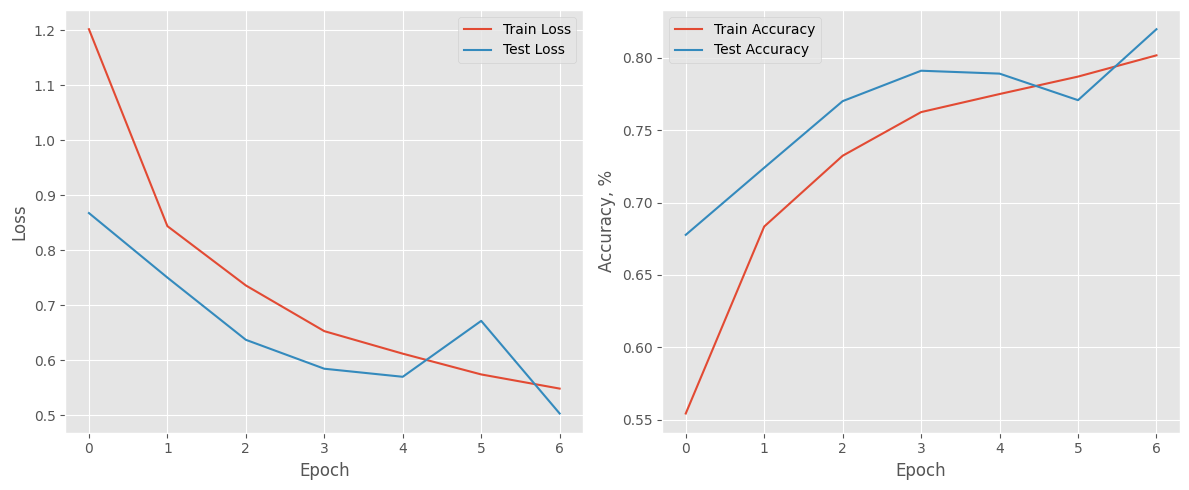

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy, %')
plt.legend()

plt.tight_layout()
plt.show()

Посмотрим, что наша модель предсказывает, на отложенной выборке. Так как для новых данных у нас отсутсвует разметка по классам, придется создать кастомный датасет для подгружения данных по частям. Подгрзить все картинки сразу нельзя - они не поместятся в оперативную память.

Создайте кастомный датасет для того, чтобы картинки подгружались динамически. [Пример можно найти здесь](https://www.learnpytorch.io/04_pytorch_custom_datasets/). Не забудьте применить трансормации, если вы использовали их при обучении модели.

Выведите пример того, что предсказывает ваша модель.


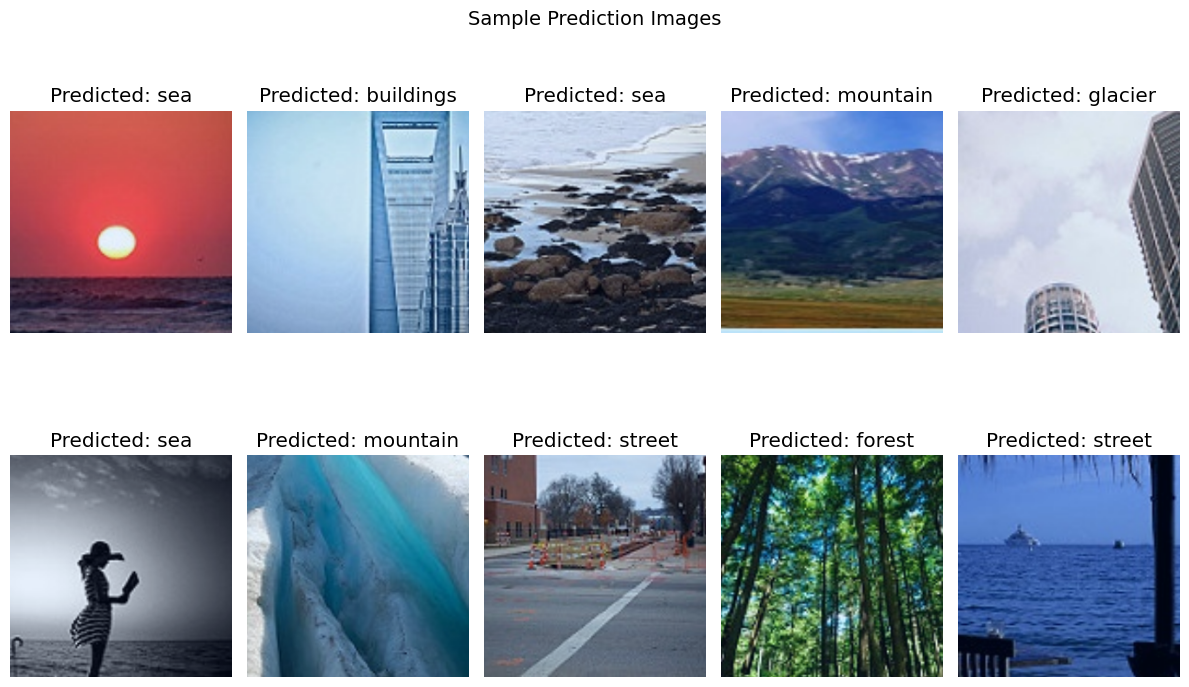

In [ ]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = [f for f in os.listdir(root_dir)
                      if f.endswith(('.jpg', '.jpeg', '.png'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.images[idx])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image

class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

pred_path = "intel-image-classification/seg_pred/seg_pred"
pred_data = CustomDataset(pred_path, transform=test_transformer)

batch_size = 10
pred_loader = DataLoader(pred_data, batch_size=batch_size, shuffle=False)

model.eval()

images = next(iter(pred_loader)).to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(12, 8))
idx = 0

for i in range(2):
    for j in range(5):
        label = class_names[predicted[idx].item()]
        ax[i, j].set_title(f"Predicted: {label}")

        img_tensor = images[idx].cpu()
        img = (255*(img_tensor - img_tensor.min()) / (img_tensor.max() - img_tensor.min())).int()          # обратное преобразование из-за трансформаций. возможно, вам оно не пригодится

        npimg = np.transpose(img.numpy(), (1, 2, 0))
        ax[i, j].imshow(npimg)
        ax[i, j].axis("off")
        idx += 1

plt.tight_layout()
plt.suptitle("Sample Prediction Images", fontsize=14)
plt.show()